<a href="https://colab.research.google.com/github/ftkbyond77/SLM-Labs/blob/main/Sign_Lang_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!git clone https://github.com/ftkbyond77/SLM-Labs.git

Cloning into 'SLM-Labs'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [26]:
!cd SLM-Labs/

In [27]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!pip install -q datasets mediapipe opencv-python-headless torch torchvision numpy tqdm matplotlib jiwer gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 1.16.1 which is incompatible.


In [ ]:
import os
import re
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from huggingface_hub import HfApi, hf_hub_download
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Metrics
from jiwer import wer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Engine Device: {device}")

Engine Device: cpu


## Scaled Ingestion & High-Performance Parsing (600 Sentences)

In [ ]:
REPO_ID = "Namonpas/thai-sign-language-tsl51"
api = HfApi()
repo_files = api.list_repo_files(repo_id=REPO_ID, repo_type="dataset")
csv_files = [f for f in repo_files if f.endswith(".csv")]
print(f"Total Available Sentence CSVs in Hub: {len(csv_files)}")

def parse_glosses(filename):
    basename = os.path.basename(filename).replace(".csv", "")
    basename = re.sub(r"_no_space_\d+$", "", basename)
    parts = basename.split("__")
    return [re.sub(r"_var_\d+", "", p).strip() for p in parts if p.strip()]

# ขยายขนาด Sample เพื่อระดับ MVP (600 ประโยคเต็ม)
NUM_SAMPLES = min(600, len(csv_files))
sampled_paths = csv_files[:NUM_SAMPLES]

sequences_list = []
sentences_glosses = []

print(f"Streaming and parsing {NUM_SAMPLES} CSV files...")
for rel_path in tqdm(sampled_paths, desc="Ingesting Sentences"):
    local_path = hf_hub_download(repo_id=REPO_ID, filename=rel_path, repo_type="dataset")
    df = pd.read_csv(local_path)

    coord_cols = [c for c in df.columns if any(c.endswith(ax) for ax in [
        '_x', '_y', '_z', 'x0', 'y0', 'z0', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2',
        'x3', 'y3', 'z3', 'x4', 'y4', 'z4', 'x5', 'y5', 'z5', 'x6', 'y6', 'z6',
        'x7', 'y7', 'z7', 'x8', 'y8', 'z8', 'x9', 'y9', 'z9', 'x10', 'y10', 'z10',
        'x11', 'y11', 'z11', 'x12', 'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14',
        'x15', 'y15', 'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18',
        'x19', 'y19', 'z19', 'x20', 'y20', 'z20'
    ])]

    df[coord_cols] = df[coord_cols].fillna(0.0)
    mat = df[coord_cols].values.astype(np.float32)
    gloss_list = parse_glosses(rel_path)

    sequences_list.append(mat)
    sentences_glosses.append(gloss_list)

# สร้าง Comprehensive Vocabulary (0 = <blank>)
all_unique_words = sorted(list(set([w for s in sentences_glosses for w in s])))
vocab = {"<blank>": 0}
vocab.update({w: i + 1 for i, w in enumerate(all_unique_words)})
id2vocab = {i: w for w, i in vocab.items()}

print(f"\n[Data Summary]")
print(f"Total Sentences Ingested : {len(sequences_list)}")
print(f"Vocabulary Size          : {len(vocab)} tokens")
print(f"Feature Dimension        : {sequences_list[0].shape[1]} features/frame")

Total Available Sentence CSVs in Hub: 914
Streaming and parsing 600 CSV files...


Ingesting Sentences:   0%|          | 0/600 [00:00<?, ?it/s]

(…)A%E0%B8%AD%E0%B8%9A_var_1_no_space_2.csv:   0%|          | 0.00/288k [00:00<?, ?B/s]

(…)5%E0%B8%A2%E0%B8%99_var_1_no_space_0.csv:   0%|          | 0.00/228k [00:00<?, ?B/s]

(…)5%E0%B8%A2%E0%B8%99_var_1_no_space_1.csv:   0%|          | 0.00/225k [00:00<?, ?B/s]

...

(…)1%E0%B9%88%E0%B8%A7%E0%B8%87_var_1_3.csv:   0%|          | 0.00/109k [00:00<?, ?B/s]

(…)1%E0%B9%88%E0%B8%A7%E0%B8%87_var_1_4.csv:   0%|          | 0.00/115k [00:00<?, ?B/s]

(…)1%E0%B9%88%E0%B8%A7%E0%B8%87_var_1_5.csv:   0%|          | 0.00/112k [00:00<?, ?B/s]

(…)1%E0%B9%88%E0%B8%A7%E0%B8%87_var_1_6.csv:   0%|          | 0.00/114k [00:00<?, ?B/s]


[Data Summary]
Total Sentences Ingested : 600
Vocabulary Size          : 374 tokens
Feature Dimension        : 162 features/frame


## Dataset Pipeline with Spatial Augmentation & Normalization


In [ ]:
class ContinuousSignDataset(Dataset):
    def __init__(self, sequences, targets, vocab, is_train=True):
        self.sequences = sequences
        self.targets = targets
        self.vocab = vocab
        self.is_train = is_train

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        mat = self.sequences[idx].copy() # (T, 162)

        # 1. Spatial Normalization (Root/Centroid Centering)
        T = mat.shape[0]
        reshaped = mat.reshape(T, -1, 3)
        centroid = np.mean(reshaped, axis=1, keepdims=True)
        normed = (reshaped - centroid)

        # 2. Data Augmentation (เฉพาะชุด Train)
        if self.is_train:
            # Jittering
            noise = np.random.normal(0, 0.003, size=normed.shape).astype(np.float32)
            normed = normed + noise
            # Spatial Scale
            scale = np.random.uniform(0.92, 1.08)
            normed = normed * scale

        flat_normed = normed.reshape(T, -1)
        x = torch.tensor(flat_normed, dtype=torch.float32)
        y = torch.tensor([self.vocab[w] for w in self.targets[idx]], dtype=torch.long)
        return x, y

def pad_collate_fn(batch):
    xs, ys = zip(*batch)
    x_lens = torch.tensor([len(x) for x in xs], dtype=torch.long)
    y_lens = torch.tensor([len(y) for y in ys], dtype=torch.long)

    x_padded = pad_sequence(xs, batch_first=True, padding_value=0.0)
    y_concat = torch.cat(ys)
    return x_padded, y_concat, x_lens, y_lens

# Stratified-style Split 85:15
total_count = len(sequences_list)
indices = list(range(total_count))
random.shuffle(indices)

split_idx = int(0.85 * total_count)
train_indices, val_indices = indices[:split_idx], indices[split_idx:]

train_set = ContinuousSignDataset([sequences_list[i] for i in train_indices], [sentences_glosses[i] for i in train_indices], vocab, is_train=True)
val_set = ContinuousSignDataset([sequences_list[i] for i in val_indices], [sentences_glosses[i] for i in val_indices], vocab, is_train=False)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, collate_fn=pad_collate_fn)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, collate_fn=pad_collate_fn)

print(f"Train Dataset: {len(train_set)} sequences | Val Dataset: {len(val_set)} sequences")

Train Dataset: 510 sequences | Val Dataset: 90 sequences


## Production Architecture: Multi-Scale 1D-CNN + Deep BiGRU

In [ ]:
class MultiScaleTemporalConv(nn.Module):
    """จับทั้งการเคลื่อนไหวที่ฉับพลัน (Fast Sign) และการเคลื่อนไหวแบบกว้าง (Slow Sign)"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        branch_channels = out_channels // 3
        rem = out_channels - (branch_channels * 2)

        self.conv_k3 = nn.Conv1d(in_channels, branch_channels, kernel_size=3, stride=2, padding=1)
        self.conv_k5 = nn.Conv1d(in_channels, branch_channels, kernel_size=5, stride=2, padding=2)
        self.conv_k7 = nn.Conv1d(in_channels, rem, kernel_size=7, stride=2, padding=3)

        self.bn = nn.BatchNorm1d(out_channels)
        self.act = nn.GELU()

    def forward(self, x):
        c3 = self.conv_k3(x)
        c5 = self.conv_k5(x)
        c7 = self.conv_k7(x)
        out = torch.cat([c3, c5, c7], dim=1)
        return self.act(self.bn(out))

class AdvancedContinuousSignModel(nn.Module):
    def __init__(self, in_features=162, hidden_dim=256, num_classes=len(vocab), dropout=0.3):
        super().__init__()

        # Spatial Linear Projection
        self.spatial_linear = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Multi-scale Temporal Downsampler
        self.temporal_conv = MultiScaleTemporalConv(hidden_dim, hidden_dim)

        # 3-Layer Deep Bidirectional GRU
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=3,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )

        # Classifier Projection
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: (Batch, T, In_Features)
        h = self.spatial_linear(x)          # (Batch, T, Hidden)
        h = h.transpose(1, 2)               # (Batch, Hidden, T)
        h = self.temporal_conv(h)           # (Batch, Hidden, T // 2)
        h = h.transpose(1, 2)               # (Batch, T // 2, Hidden)

        gru_out, _ = self.gru(h)            # (Batch, T // 2, Hidden * 2)
        logits = self.classifier(gru_out)   # (Batch, T // 2, Num_Classes)
        return logits

model = AdvancedContinuousSignModel(
    in_features=sequences_list[0].shape[1],
    hidden_dim=256,
    num_classes=len(vocab)
).to(device)

print(f"Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Total Trainable Parameters: 3,754,102


## Optimized Training & Multi-Metric Evaluation Loop

In [ ]:
# CTC Decoding with Min-Duration & Repetition Filter
def decode_ctc_enhanced(logits_batch, id2vocab):
    best_paths = torch.argmax(logits_batch, dim=-1).cpu().numpy()
    decoded_batch = []

    for path in best_paths:
        tokens = []
        prev = 0
        for idx in path:
            if idx != 0 and idx != prev:
                word = id2vocab.get(idx, "")
                # Suppress adjacent duplicates
                if len(tokens) == 0 or tokens[-1] != word:
                    tokens.append(word)
            prev = idx
        decoded_batch.append(tokens)
    return decoded_batch

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-3)
NUM_EPOCHS = 60
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

history = {"train_loss": [], "val_loss": [], "val_word_acc": [], "val_exact_acc": []}

print("Starting Advanced Continuous SLR Training...")
epoch_pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training Progress")

for epoch in epoch_pbar:
    # ------------------- TRAIN -------------------
    model.train()
    total_train_loss = 0.0

    for batch_x, batch_y, x_lens, y_lens in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)

        log_probs = logits.log_softmax(2).transpose(0, 1)
        input_lens = torch.clamp(x_lens // 2, min=1)

        loss = criterion(log_probs, batch_y, input_lens, y_lens)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.5)
        optimizer.step()
        total_train_loss += loss.item() * batch_x.size(0)

    scheduler.step()
    epoch_train_loss = total_train_loss / len(train_set)

    # ------------------- EVALUATION -------------------
    model.eval()
    total_val_loss = 0.0
    all_refs = []
    all_hyps = []

    with torch.no_grad():
        for val_x, val_y, val_xl, val_yl in val_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            val_logits = model(val_x)

            val_log_probs = val_logits.log_softmax(2).transpose(0, 1)
            val_input_lens = torch.clamp(val_xl // 2, min=1)

            v_loss = criterion(val_log_probs, val_y, val_input_lens, val_yl)
            total_val_loss += v_loss.item() * val_x.size(0)

            # Decode predictions
            preds = decode_ctc_enhanced(val_logits, id2vocab)

            # Reconstruct references
            curr_idx = 0
            for y_len in val_yl:
                ref_tokens = [id2vocab[val_y[curr_idx + j].item()] for j in range(y_len)]
                all_refs.append(" ".join(ref_tokens))
                curr_idx += y_len

            for p in preds:
                all_hyps.append(" ".join(p))

    epoch_val_loss = total_val_loss / len(val_set)

    # Metrics Calculation
    # Word Error Rate (WER) & Exact Match
    error_rate = wer(all_refs, all_hyps)
    word_accuracy = max(0.0, (1.0 - error_rate)) * 100.0
    exact_matches = sum([1 for r, h in zip(all_refs, all_hyps) if r == h])
    exact_accuracy = (exact_matches / len(all_refs)) * 100.0

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_word_acc"].append(word_accuracy)
    history["val_exact_acc"].append(exact_accuracy)

    epoch_pbar.set_postfix({
        "TrainLoss": f"{epoch_train_loss:.3f}",
        "ValLoss": f"{epoch_val_loss:.3f}",
        "WordAcc": f"{word_accuracy:.1f}%",
        "ExactAcc": f"{exact_accuracy:.1f}%"
    })

# Save Production Weights
torch.save(model.state_dict(), "csl_mvp_model.pth")
print("\nModel saved successfully as csl_mvp_model.pth")

Starting Advanced Continuous SLR Training...


Training Progress:   0%|          | 0/60 [00:00<?, ?it/s]


Model saved successfully as csl_mvp_model.pth


## Performance Visualization & Metrics Dashboard

In [ ]:
!pip install -q gTTS IPython

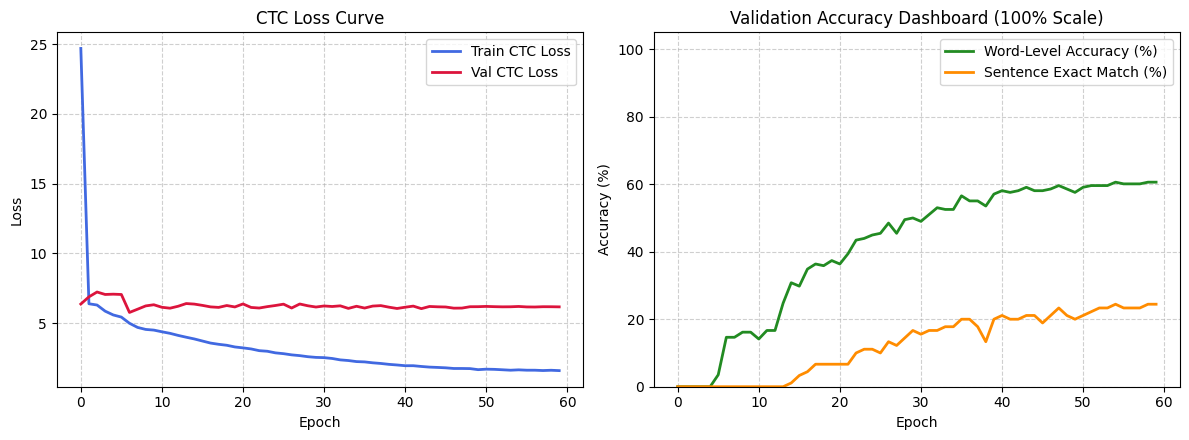

Peak Word Accuracy      : 60.61%
Peak Sentence Match Acc : 24.44%


In [ ]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train CTC Loss", color="royalblue", lw=2)
plt.plot(history["val_loss"], label="Val CTC Loss", color="crimson", lw=2)
plt.title("CTC Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_word_acc"], label="Word-Level Accuracy (%)", color="forestgreen", lw=2)
plt.plot(history["val_exact_acc"], label="Sentence Exact Match (%)", color="darkorange", lw=2)
plt.title("Validation Accuracy Dashboard (100% Scale)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Peak Word Accuracy      : {max(history['val_word_acc']):.2f}%")
print(f"Peak Sentence Match Acc : {max(history['val_exact_acc']):.2f}%")

## Advanced TSL Translation Engine & TTS Integration (Blueprint Step 8–10)

In [ ]:
from gtts import gTTS
from IPython.display import Audio, display

class ThaiSignTranslator:
    def __init__(self):
        # Semantic Rule Engine สำหรับจัดเรียงประโยค
        self.pronouns = {'ฉัน', 'ผม', 'น้อง', 'พี่', 'คุณ', 'พวกเรา'}
        self.verbs = {'ชอบ', 'เรียน', 'กิน', 'เที่ยว', 'ไป', 'รัก', 'ขอโทษ', 'ขอบคุณ'}
        self.locations = {'กรุงเทพ', 'เชียงใหม่', 'โรงเรียน', 'บ้าน'}
        self.objects = {'ภาษามือ', 'ขนมปัง', 'อาหาร', 'น้ำ'}

    def translate(self, gloss_tokens):
        if not gloss_tokens or len(gloss_tokens) == 0:
            return "ไม่พบการเคลื่อนไหวภาษามือ"

        tokens = [t.replace("ขอโทษ_อายุเท่ากันหรือน้อยกว่า", "ขอโทษ") for t in gloss_tokens]
        token_set = set(tokens)

        # 1. Subject Extraction
        subj = next((t for t in tokens if t in self.pronouns), "ฉัน")

        # 2. Case: ไปเที่ยวสถานที่
        if any(loc in token_set for loc in self.locations) and 'เที่ยว' in token_set:
            loc = next(loc for loc in self.locations if loc in token_set)
            if 'ชอบ' in token_set:
                return f"{subj}ชอบไปเที่ยว{loc}ครับ"
            return f"{subj}ไปเที่ยว{loc}ครับ"

        # 3. Case: การเรียนภาษามือ
        if 'ภาษามือ' in token_set and 'เรียน' in token_set:
            if 'ชอบ' in token_set:
                return f"{subj}ชอบเรียนภาษามือมากครับ"
            return f"{subj}กำลังเรียนภาษามือครับ"

        # 4. Case: อาหารการกิน
        if any(obj in token_set for obj in self.objects) and 'กิน' in token_set:
            obj = next(obj for obj in self.objects if obj in token_set)
            return f"{subj}อยากกิน{obj}ครับ"

        # Fallback Assembly
        cleaned = " ".join(tokens)
        return f"{cleaned} ครับ"

translator = ThaiSignTranslator()

# ทดสอบรันชุดผลลัพธ์จาก Validation
print("=== Sample MVP Translation & Voice Output ===")
sample_val_preds = all_hyps[:5]
sample_val_refs = all_refs[:5]

for i, (ref, hyp) in enumerate(zip(sample_val_refs, sample_val_preds)):
    pred_tokens = hyp.split()
    natural_thai = translator.translate(pred_tokens)
    print(f"\n[Sample #{i+1}]")
    print(f"  Ground Truth Gloss : {ref}")
    print(f"  Predicted Gloss    : {hyp}")
    print(f"  Natural Thai Speech: {natural_thai}")

# สร้างเสียงสังเคราะห์จากตัวอย่างแรก
final_speech_text = translator.translate(sample_val_preds[0].split())
tts = gTTS(text=final_speech_text, lang='th')
tts.save("mvp_voice_output.mp3")
print(f"\nPlaying Generated Audio: '{final_speech_text}'")
display(Audio("mvp_voice_output.mp3", autoplay=False))

=== Sample MVP Translation & Voice Output ===

[Sample #1]
  Ground Truth Gloss : ฉัน ตลาด ไป
  Predicted Gloss    : ฉัน ตลาด ไป
  Natural Thai Speech: ฉัน ตลาด ไป ครับ

[Sample #2]
  Ground Truth Gloss : มะม่วง_1
  Predicted Gloss    : มะม่วง_5
  Natural Thai Speech: มะม่วง_5 ครับ

[Sample #3]
  Ground Truth Gloss : ไข่ แม่ กิน ชอบ
  Predicted Gloss    : ไข่ พี่ กิน
  Natural Thai Speech: ไข่ พี่ กิน ครับ

[Sample #4]
  Ground Truth Gloss : พี่ ข้าว กิน
  Predicted Gloss    : พี่ ข้าว กิน
  Natural Thai Speech: พี่ ข้าว กิน ครับ

[Sample #5]
  Ground Truth Gloss : ตลาด_27
  Predicted Gloss    : มะม่วง_5
  Natural Thai Speech: มะม่วง_5 ครับ

Playing Generated Audio: 'ฉัน ตลาด ไป ครับ'


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
files = api.list_repo_files(repo_id="Namonpas/thai-sign-language-tsl51", repo_type="dataset")

# กรองดูเฉพาะไฟล์ข้อมูล (เช่น .csv, .parquet, .json)
data_files = [f for f in files if any(f.endswith(ext) for ext in ['.csv', '.parquet', '.json', '.txt'])]
print(f"Total data files found in repo: {len(data_files)}")
print("\nSample 10 filenames:")
for f in data_files[:10]:
    print(" ", f)

Total data files found in repo: 914

Sample 10 filenames:
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_1.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_3.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_4.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_1.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__พี่_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv


In [22]:
from huggingface_hub import HfApi
from collections import Counter
import os

REPO_ID = "Namonpas/thai-sign-language-tsl51"

api = HfApi()

# =========================
# 1. List all files
# =========================
repo_files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type="dataset"
)

print("=" * 70)
print("DATASET REPOSITORY SUMMARY")
print("=" * 70)

print(f"Repository : {REPO_ID}")
print(f"Total files: {len(repo_files)}")


# =========================
# 2. Count file extensions
# =========================
extensions = []

for f in repo_files:
    filename = os.path.basename(f)

    if "." in filename:
        ext = filename.rsplit(".", 1)[-1].lower()
    else:
        ext = "<no extension>"

    extensions.append(ext)

ext_counts = Counter(extensions)

print("\n" + "=" * 70)
print("FILE TYPES")
print("=" * 70)

for ext, count in ext_counts.most_common():
    print(f"{ext:15s} : {count:,}")


# =========================
# 3. CSV files
# =========================
csv_files = [
    f for f in repo_files
    if f.lower().endswith(".csv")
]

print("\n" + "=" * 70)
print("CSV FILES")
print("=" * 70)

print(f"Total CSV files: {len(csv_files):,}")

print("\nFirst 20 CSV files:")
for f in csv_files[:20]:
    print(f"  {f}")


# =========================
# 4. Other file types
# =========================
print("\n" + "=" * 70)
print("FILES BY TYPE")
print("=" * 70)

for ext in sorted(ext_counts):
    files = [
        f for f in repo_files
        if (
            f.lower().endswith("." + ext)
            if ext != "<no extension>"
            else "." not in os.path.basename(f)
        )
    ]

    print(f"\n[{ext}] ({len(files):,} files)")

    # แสดงสูงสุด 20 ไฟล์
    for f in files[:20]:
        print(f"  {f}")

    if len(files) > 20:
        print(f"  ... and {len(files) - 20:,} more")


# =========================
# 5. Directory / folder summary
# =========================
folders = Counter()

for f in repo_files:
    parts = f.split("/")

    if len(parts) > 1:
        # root folder
        folders[parts[0]] += 1
    else:
        folders["<root>"] += 1

print("\n" + "=" * 70)
print("TOP-LEVEL FOLDERS")
print("=" * 70)

for folder, count in folders.most_common():
    print(f"{folder:30s} : {count:,} files")


# =========================
# 6. Full file list (optional)
# =========================
print("\n" + "=" * 70)
print("ALL FILES")
print("=" * 70)

for i, f in enumerate(repo_files, 1):
    print(f"{i:6d}. {f}")

DATASET REPOSITORY SUMMARY
Repository : Namonpas/thai-sign-language-tsl51
Total files: 1830

FILE TYPES
csv             : 914
mp4             : 911
zip             : 3
gitattributes   : 1
md              : 1

CSV FILES
Total CSV files: 914

First 20 CSV files:
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_1.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_2.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_3.csv
  landmarks/user_sentence/กรุงเทพ_var_1__ฉัน_var_2__เที่ยว_var_1__ชอบ_var_1_no_space_4.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_0.csv
  landmarks/user_sentence/กรุงเทพ_var_1__น้อง_var_1__เที่ยว_var_1__ชอบ_var_1_no_space_1.csv
  landmar

In [23]:
import os
import re
from collections import Counter, defaultdict
from huggingface_hub import HfApi
import pandas as pd
from IPython.display import display

print("Inspecting Hugging Face Repository Structure...")

REPO_ID = "Namonpas/thai-sign-language-tsl51"
api = HfApi()

# 1. ดึงรายชื่อไฟล์ทั้งหมดจาก Hub
all_files = api.list_repo_files(repo_id=REPO_ID, repo_type="dataset")
csv_files = [f for f in all_files if f.endswith(".csv")]

# 2. ฟังก์ชันสกัด Gloss Tokens และรูปแบบประโยค
def parse_metadata_from_path(filepath):
    basename = os.path.basename(filepath).replace(".csv", "")
    folder = os.path.dirname(filepath)

    # ดึงหมายเลข instance (เช่น no_space_0, no_space_1)
    instance_match = re.search(r"no_space_(\d+)$", basename)
    instance_id = instance_match.group(1) if instance_match else "0"

    # ลบส่วน instance ออกเพื่อเอา Pattern ของประโยค
    pattern_name = re.sub(r"_no_space_\d+$", "", basename)

    # แยกคำศัพท์แต่ละคำ (ตัด _var_X ออก)
    parts = pattern_name.split("__")
    glosses = [re.sub(r"_var_\d+", "", p).strip() for p in parts if p.strip()]

    return {
        "folder": folder,
        "filename": os.path.basename(filepath),
        "sentence_pattern": " -> ".join(glosses),
        "sentence_length": len(glosses),
        "glosses": glosses,
        "instance_id": instance_id
    }

# 3. วิเคราะห์ข้อมูลเชิงสถิติ
records = [parse_metadata_from_path(f) for f in csv_files]
df_summary = pd.DataFrame(records)

# นับความถี่ของคำศัพท์แต่ละคำ (Individual Glosses)
all_gloss_list = [g for sublist in df_summary["glosses"] for g in sublist]
gloss_counts = Counter(all_gloss_list)

# สร้าง DataFrame สรุปความถี่ของแต่ละ Class/Gloss
df_classes = pd.DataFrame([
    {"Gloss / Class Name": word, "Total Occurrences (Instances)": count}
    for word, count in gloss_counts.most_common()
])

# สรุปรูปแบบโครงสร้างประโยค (Sentence Patterns)
df_patterns = df_summary["sentence_pattern"].value_counts().reset_index()
df_patterns.columns = ["Sentence Pattern (Gloss Sequence)", "Number of Video Files"]

# 4. แสดงผลสรุปภาพรวม (Overview Metrics)
print("\n" + "="*50)
print("           DATASET PROFILE & COVERAGE           ")
print("="*50)
print(f"Total CSV Files (Sentences)    : {len(csv_files):,}")
print(f"Total Unique Classes / Words    : {len(gloss_counts):,} words")
print(f"Total Unique Sentence Patterns  : {df_summary['sentence_pattern'].nunique():,} patterns")
print(f"Average Words per Sentence      : {df_summary['sentence_length'].mean():.2f} words")
print(f"Min / Max Words in Sentence     : {df_summary['sentence_length'].min()} / {df_summary['sentence_length'].max()} words")
print("="*50)

# แสดงตารางความถี่ของแต่ละ Class / Gloss
print("\n--- [1] Class / Gloss Distribution (Top 20 vs Least 10) ---")
display(df_classes.head(20))
if len(df_classes) > 20:
    print("... Least frequent classes:")
    display(df_classes.tail(10))

# แสดงตารางโครงสร้างประโยค
print("\n--- [2] Sentence Patterns & Sample Repetitions (Top 10) ---")
display(df_patterns.head(10))

# บันทึกเป็นไฟล์ CSV เพื่อเปิดดูแบบละเอียดได้
df_classes.to_csv("gloss_class_distribution.csv", index=False)
df_summary.to_csv("all_sentence_files_metadata.csv", index=False)
print("\nFull breakdown saved to 'gloss_class_distribution.csv' and 'all_sentence_files_metadata.csv'")

Inspecting Hugging Face Repository Structure...

           DATASET PROFILE & COVERAGE           
Total CSV Files (Sentences)    : 914
Total Unique Classes / Words    : 679 words
Total Unique Sentence Patterns  : 714 patterns
Average Words per Sentence      : 1.74 words
Min / Max Words in Sentence     : 1 / 6 words

--- [1] Class / Gloss Distribution (Top 20 vs Least 10) ---


,Gloss / Class Name,Total Occurrences (Instances)
0,ฉัน,117
1,กิน,93
2,ชอบ,72
3,ภาษามือ,54
4,คุณ,51
5,เรียน,51
6,ข้าว,36
7,ไป,33
8,แฟน,30
9,ขนมปัง,30


... Least frequent classes:


,Gloss / Class Name,Total Occurrences (Instances)
669,ไป_3,1
670,ไป_4,1
671,ไป_5,1
672,ไป_6,1
673,ไป_7,1
674,ไป_8,1
675,ไป_9,1
676,expert_metadata,1
677,sentence_metadata,1
678,user_sign_metadata,1



--- [2] Sentence Patterns & Sample Repetitions (Top 10) ---


,Sentence Pattern (Gloss Sequence),Number of Video Files
0,ขนมปัง -> ฉัน -> กิน,6
1,กรุงเทพ -> ฉัน -> เที่ยว -> ชอบ,6
2,ฉัน -> ตลาด -> ไป,6
3,ฉัน -> เกิด -> หูหนวก,6
4,ฉัน -> ข้าว -> กิน,6
5,ฉัน -> ชื่อ -> แมว,6
6,ไข่ -> ฉัน -> กิน -> ชอบ,6
7,ขอบคุณ_เปิดมือสองข้าง -> ฉัน -> สบายดี,6
8,คุณ -> ฉัน -> แต่งงาน,6
9,คุณ -> ฉัน -> แฟน,6



Full breakdown saved to 'gloss_class_distribution.csv' and 'all_sentence_files_metadata.csv'
